# 情報数学Ⅲ 第14回

### 🔍 利用方法

- このノートブックは**閲覧専用**です。  
  自分のGoogleドライブにコピーを作成してから編集してください。

  1. メニューの「**ファイル → ドライブにコピーを保存**」を選ぶ  
  2. コピーしたノートブックの**ファイル名（左上の"xxxx"）を学籍番号に変更**してください（提出時の識別のため）

---

### 🔧 提出手順

1. Google Colab の右上にある「**共有**」ボタンをクリック  
2. 「**一般的なアクセス**」の設定を「**リンクを知っている全員**」に変更  
3. アクセス権を「**閲覧者**」に設定（⚠️「編集者」にしないこと！）  
4. 表示されるURLをコピー  
5. WebClassの提出フォームに、その**URLを貼り付けて提出**

---

### 💡 補足・注意点

- **「編集者」ではなく「閲覧者」**に設定してください。  
  → 教員が間違ってファイルを上書きしてしまうのを防ぐためです。
- **提出したリンクを自分でも一度開いてみて、ちゃんと共有されているかを確認**してください。

In [2]:
# 使用するライブラリのインポート
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gamma
import seaborn as sns

# 日本語表示: Colab環境用
#!pip install japanize_matplotlib
#import japanize_matplotlib

# 日本語表示: 教員確認用（Mac）
# 日本語フォントを指定（ヒラギノ角ゴがmacOSに標準搭載）
plt.rcParams['font.family'] = 'Hiragino Sans'


## 例題1：年齢と年収をもう一度・・・



In [3]:
# 年齢と収入のデータを含むリスト
data = [
    {"name": "A", "age": 38, "income": 500},
    {"name": "B", "age": 30, "income": 270},
    {"name": "C", "age": 28, "income": 450},
    {"name": "D", "age": 55, "income": 400},
    {"name": "E", "age": 38, "income": 250},
    {"name": "F", "age": 48, "income": 600},
    {"name": "G", "age": 30, "income": 400},
    {"name": "H", "age": 25, "income": 300},
    {"name": "I", "age": 56, "income": 800},
    {"name": "J", "age": 42, "income": 530}
]

### データフレームにする


In [4]:
df = pd.DataFrame(data)
df.head()

,name,age,income
0,A,38,500
1,B,30,270
2,C,28,450
3,D,55,400
4,E,38,250


### 回帰分析の実施

In [5]:
# 線形回帰
linear_model = smf.ols("income ~ age", data=df).fit()

# 予測値をデータフレームに追加
df["pred_linear"] = linear_model.predict(df)

# 線形回帰の結果の概要
print(linear_model.summary())

                            OLS Regression Results                            
Dep. Variable:                 income   R-squared:                       0.432
Model:                            OLS   Adj. R-squared:                  0.361
Method:                 Least Squares   F-statistic:                     6.081
Date:                Tue, 15 Jul 2025   Prob (F-statistic):             0.0390
Time:                        23:31:47   Log-Likelihood:                -62.071
No. Observations:                  10   AIC:                             128.1
Df Residuals:                       8   BIC:                             128.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     63.4946    162.380      0.391      0.7

/Users/gsuzuki/pyenvs/ds/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=10 observations were given.
  return hypotest_fun_in(*args, **kwds)


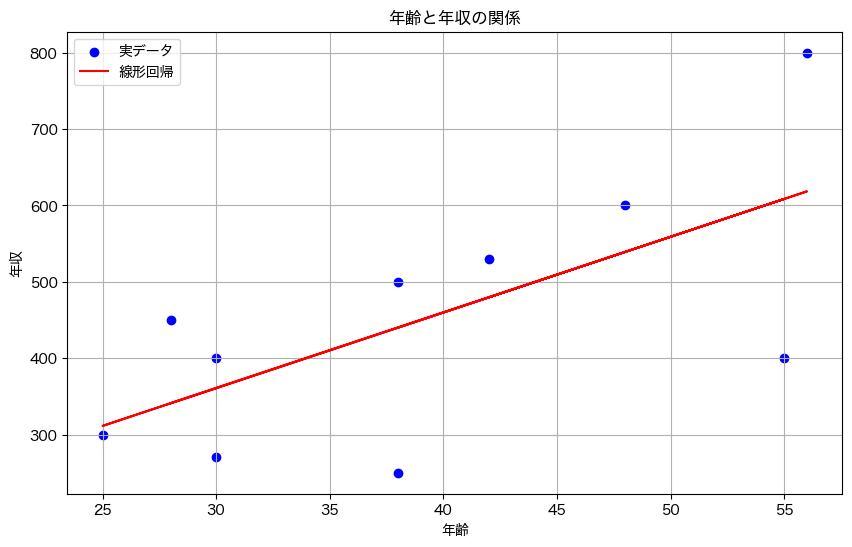

In [6]:
# プロット
plt.figure(figsize=(10, 6))
plt.scatter(df["age"], df["income"], label="実データ", color="blue")
plt.plot(df["age"], df["pred_linear"], label="線形回帰", color="red")
plt.xlabel("年齢")
plt.ylabel("年収")
plt.title("年齢と年収の関係")
plt.legend()
plt.grid()
plt.show()

### ガンマ回帰で使う関数：対数関数

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

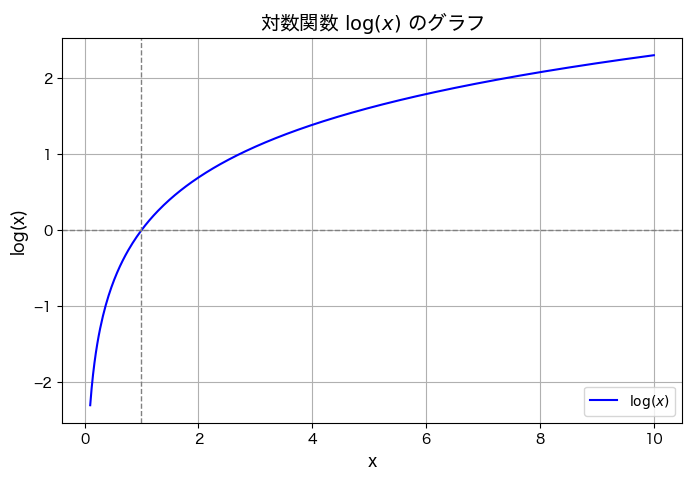

In [7]:
#　対数関数のグラフ（説明用）

# x > 0 の範囲で値を生成
x = np.linspace(0.1, 10, 400)
y = np.log(x)

# グラフの描画
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=r"$\log(x)$", color="blue")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)  # y=0 の線
plt.axvline(1, color="gray", linestyle="--", linewidth=1)  # x=1 の線
plt.title("対数関数 $\\log(x)$ のグラフ", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("log(x)", fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout

### ガンマ回帰で使う確率分布：ガンマ分布

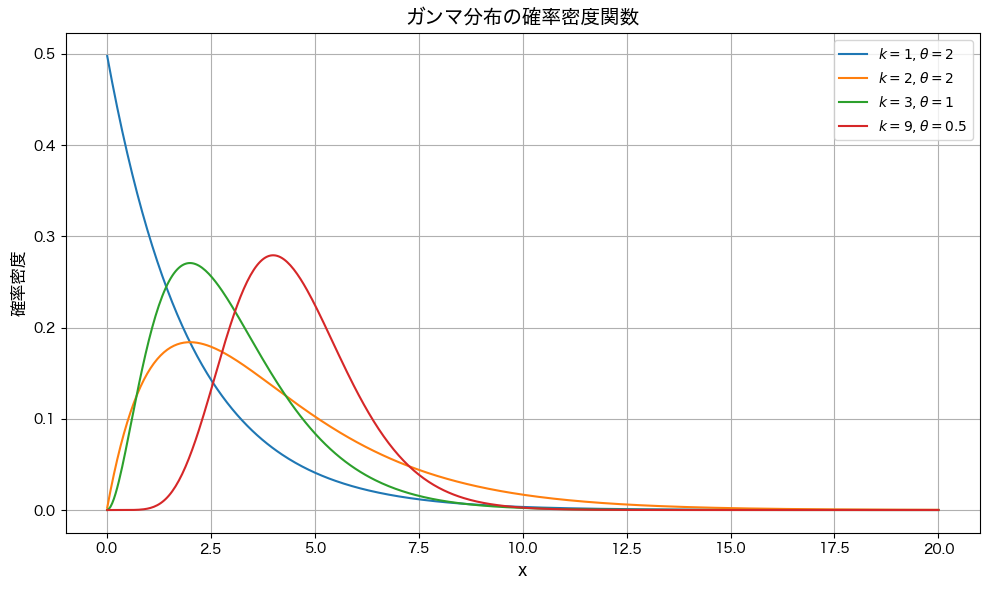

In [8]:
# x軸の値（正の範囲）
x = np.linspace(0.01, 20, 500)

# ガンマ分布のパラメータ例（shape=k, scale=θ）
params = [
    {"k": 1, "theta": 2},
    {"k": 2, "theta": 2},
    {"k": 3, "theta": 1},
    {"k": 9, "theta": 0.5},
]

# グラフの描画
plt.figure(figsize=(10, 6))
for param in params:
    k = param["k"]
    theta = param["theta"]
    y = gamma.pdf(x, a=k, scale=theta)
    label = fr"$k={k}, \theta={theta}$"
    plt.plot(x, y, label=label)

plt.title("ガンマ分布の確率密度関数", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("確率密度", fontsize=12)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### ガンマ回帰の実施

In [9]:
# ガンマ回帰（logリンク）
# 目的変数はガンマ分布に従うと仮定

# リンク関数に対数関数を使用
gamma_model = smf.glm("income ~ age", data=df,
                      family=sm.families.Gamma(link=sm.families.links.log())).fit()

# 参考：リンク関数の指定を省略すると，デフォルトの1/xとなる．少し結果は変わる）
#gamma_model = smf.glm("income ~ age", data=df,
#                      family=sm.families.Gamma()).fit()

# 予測値をデータフレームに追加
df["pred_gamma"] = gamma_model.predict(df)

# ガンマ回帰の結果の概要
print(gamma_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:                 income   No. Observations:                   10
Model:                            GLM   Df Residuals:                        8
Model Family:                   Gamma   Df Model:                            1
Link Function:                    log   Scale:                        0.075353
Method:                          IRLS   Log-Likelihood:                -61.429
Date:                Tue, 15 Jul 2025   Deviance:                      0.69626
Time:                        23:31:47   Pearson chi2:                    0.603
No. Iterations:                     7   Pseudo R-squ. (CS):             0.4978
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.2539      0.332     15.824      0.0

/Users/gsuzuki/pyenvs/ds/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


### 線形回帰とガンマ回帰の結果を図示

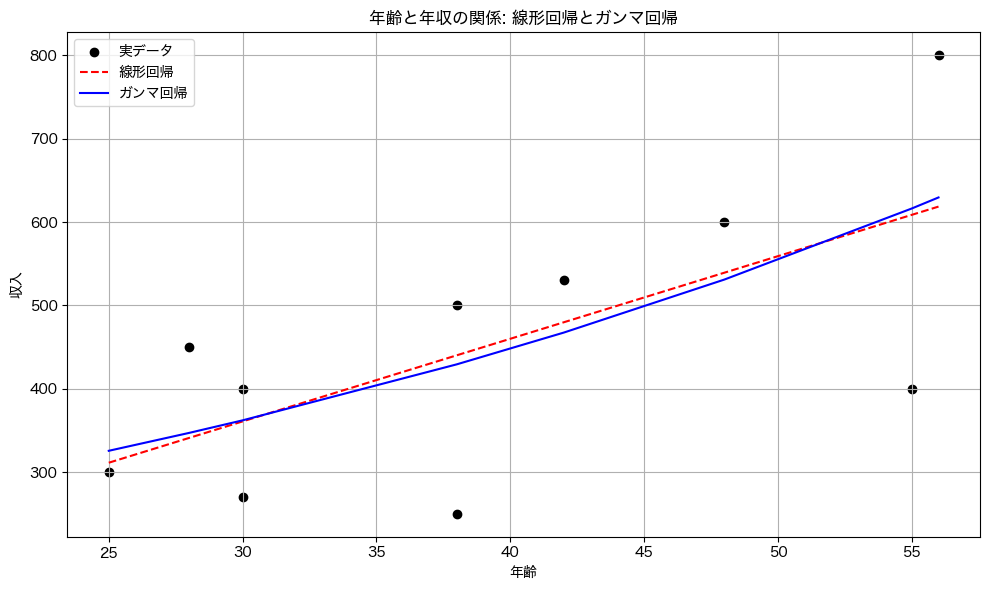

In [10]:
# データを年齢順に並べる
df_sorted = df.sort_values("age")

plt.figure(figsize=(10, 6))
plt.scatter(df["age"], df["income"], color="black", label="実データ")
plt.plot(df_sorted["age"], df_sorted["pred_linear"], "r--", label="線形回帰")
plt.plot(df_sorted["age"], df_sorted["pred_gamma"], "b-", label="ガンマ回帰")
plt.xlabel("年齢")
plt.ylabel("収入")
plt.title("年齢と年収の関係: 線形回帰とガンマ回帰")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 例題：ポアソン回帰

教科書の例題を使用

In [26]:
# 必要なデータファイルを取得
import requests

base_url = "https://raw.githubusercontent.com/logics-of-blue/book-python-stats-2nd/refs/heads/main/book-data/"
filenames = [
    "9-4-1-poisson-regression.csv"
]

for filename in filenames:
    url = base_url + filename
    print(f"Downloading {filename}...")
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, "wb") as f:
            f.write(response.content)
    else:
        print(f"Failed to download {filename}: {response.status_code}")

In [27]:
# データの読み込み
beer = pd.read_csv('9-4-1-poisson-regression.csv')
print(beer.head(3))

   beer_number  temperature
0            6         17.5
1           11         26.6
2            2          5.0


In [28]:
# モデル化
mod_pois = smf.glm('beer_number ~ temperature', beer, 
                   family=sm.families.Poisson()).fit()
print(mod_pois.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:            beer_number   No. Observations:                   30
Model:                            GLM   Df Residuals:                       28
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -57.672
Date:                Wed, 16 Jul 2025   Deviance:                       5.1373
Time:                        00:06:07   Pearson chi2:                     5.40
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9708
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.4476      0.199      2.253      

<Axes: xlabel='temperature', ylabel='beer_number'>

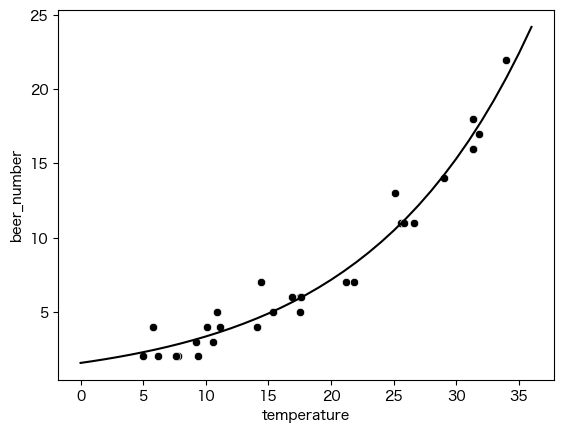

In [29]:
# 予測値の作成
x_plot = np.arange(0, 37)
pred = mod_pois.predict(pd.DataFrame({'temperature': x_plot}))

# 散布図
sns.scatterplot(x='temperature', y='beer_number',
                data=beer, color='black')
# 回帰曲線を上書き
sns.lineplot(x=x_plot, y=pred, color='black')

### 回帰係数の解釈

In [30]:
# 気温が1℃のときの販売個数の期待値
exp_val_1 = pd.DataFrame({'temperature': [1]})
pred_1 = mod_pois.predict(exp_val_1)

# 気温が2℃のときの販売個数の期待値
exp_val_2 = pd.DataFrame({'temperature': [2]})
pred_2 = mod_pois.predict(exp_val_2)

# 気温が1℃上がると、販売個数は何倍になるか
round(pred_2 / pred_1, 3)

0    1.079
dtype: float64

In [31]:
# 係数のexpをとる
round(np.exp(mod_pois.params['temperature']), 3)

np.float64(1.079)

## 演習：ポアソン回帰

バイクシェアリングの例

* 目的変数：cnt（その日のレンタル数）
* 説明変数：temp（気温→注意：正規化済み）、season、weekday、holiday など

In [19]:
url = "https://raw.githubusercontent.com/ggszk/ggszk-lab-public/refs/heads/main/csv/day.csv"
df = pd.read_csv(url)
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


### 気温とレンタル数の関係をポアソン回帰で調べよう

* 注意：この例は，あまりうまくモデル化はできていない．

In [16]:
# 気温とレンタル数の関係をポアソン回帰で調べよう
mod_pois = smf.glm('cnt ~ temp', df, 
                   family=sm.families.Poisson()).fit()
print(mod_pois.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    cnt   No. Observations:                  731
Model:                            GLM   Df Residuals:                      729
Model Family:                 Poisson   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.1693e+05
Date:                Tue, 15 Jul 2025   Deviance:                   4.2646e+05
Time:                        23:31:49   Pearson chi2:                 4.09e+05
No. Iterations:                     5   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.6291      0.002   4295.378      0.0

### データを可視化しよう


<Axes: xlabel='temp', ylabel='cnt'>

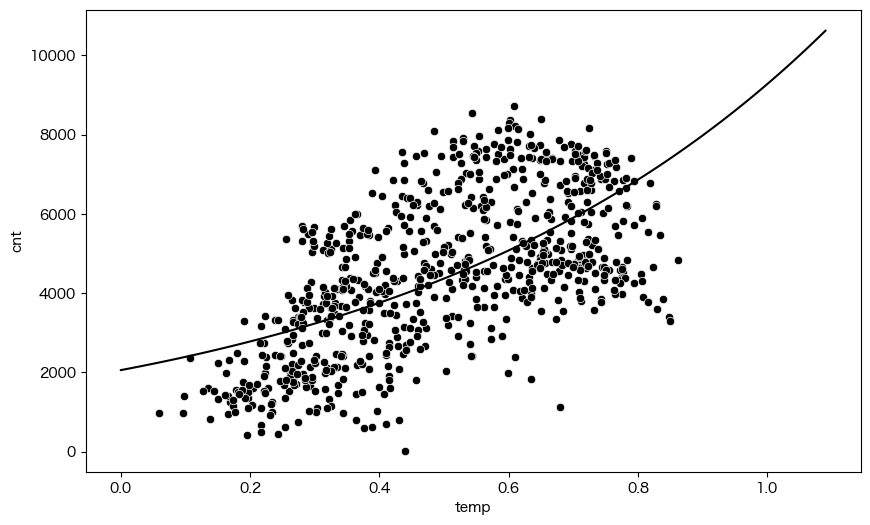

In [ ]:
# データを可視化しよう
# tempは正規化済み
plt.figure(figsize=(10, 6))
sns.scatterplot(x='temp', y='cnt', data=df, color='black')
# 回帰曲線
x_plot = np.arange(0, 1.1, 0.01)
pred = mod_pois.predict(pd.DataFrame({'temp': x_plot}))
sns.lineplot(x=x_plot, y=pred, color='black')   